In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [5]:
import pandas as pd

df = pd.read_csv("/content/Sentiment_Analysis.csv",
    encoding="latin-1",
    header=None,
    engine="python",
    on_bad_lines="skip"
)
df

,0,1,2,3
0,tweet_id,sentiment,author,content
1,1956967341,empty,xoshayzers,@tiffanylue i know i was listenin to bad habi...
2,1956967666,sadness,wannamama,Layin n bed with a headache ughhhh...waitin o...
3,1956967696,sadness,coolfunky,Funeral ceremony...gloomy friday...
4,1956967789,enthusiasm,czareaquino,wants to hang out with friends SOON!
...,...,...,...,...
39996,1753918954,neutral,showMe_Heaven,@JohnLloydTaylor
39997,1753919001,love,drapeaux,Happy Mothers Day All my love
39998,1753919005,love,JenniRox,Happy Mother's Day to all the mommies out ther...
39999,1753919043,happiness,ipdaman1,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...


In [6]:
print(df.columns)

Index([0, 1, 2, 3], dtype='int64')


In [8]:
# The original df has the header in the first row because of header=None.
# Drop the header row (index 0) from the DataFrame to clean the data.
df = df.iloc[1:].copy()
df.reset_index(drop=True, inplace=True)

# Column 1 in df now contains the actual string sentiments.
# Define a mapping for the various string sentiments to a simplified set.
sentiment_mapping = {
    'empty': 'Negative',
    'sadness': 'Negative',
    'worry': 'Negative',
    'hate': 'Negative',
    'anger': 'Negative',
    'boredom': 'Neutral',
    'neutral': 'Neutral',
    'surprise': 'Neutral',
    'love': 'Positive',
    'happiness': 'Positive',
    'fun': 'Positive',
    'enthusiasm': 'Positive',
    'joy': 'Positive',
    'relief': 'Positive'
}

# Apply the mapping to the sentiment column (column 1).
df[1] = df[1].replace(sentiment_mapping)

# Rename columns 1 to 'sentiment' and 3 to 'tweet' for clarity and downstream use.
df.rename(columns={1: 'sentiment', 3: 'tweet'}, inplace=True)

In [9]:
df.dropna(inplace=True)

In [10]:
X = df["tweet"]
y = df["sentiment"]

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Model
model = MultinomialNB()
model.fit(X_train_vec, y_train)


MultinomialNB()

In [13]:
y_pred = model.predict(X_test_vec)

In [15]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.54875
              precision    recall  f1-score   support

    Negative       0.55      0.76      0.64      3161
     Neutral       0.43      0.19      0.26      2196
    Positive       0.59      0.59      0.59      2643

    accuracy                           0.55      8000
   macro avg       0.52      0.51      0.50      8000
weighted avg       0.53      0.55      0.52      8000



In [17]:
from sklearn.metrics import confusion_matrix

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

              precision    recall  f1-score   support

    Negative       0.55      0.76      0.64      3161
     Neutral       0.43      0.19      0.26      2196
    Positive       0.59      0.59      0.59      2643

    accuracy                           0.55      8000
   macro avg       0.52      0.51      0.50      8000
weighted avg       0.53      0.55      0.52      8000


Confusion Matrix
[[2416  291  454]
 [1168  409  619]
 [ 836  242 1565]]


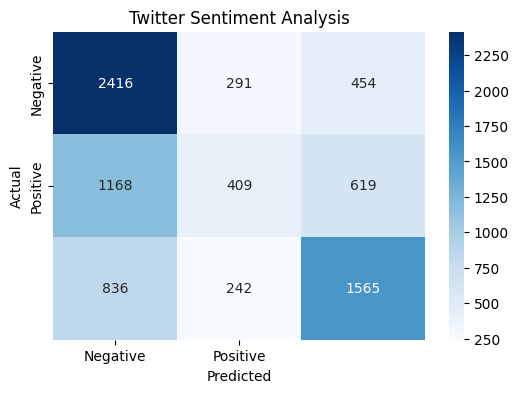

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Twitter Sentiment Analysis")

plt.show()

In [21]:
tweet = input("Enter Tweet: ")

tweet_vec = vectorizer.transform([tweet])

prediction = model.predict(tweet_vec)

print("Sentiment:", prediction[0])


Enter Tweet: I'm happy
Sentiment: Positive
